# 1D Inviscid Burgers Solver — API Test Notebook

Interactive visual sanity checks for the `numerical_solvers.burgers` public API:
- Flux `f(u) = u^2/2` and Godunov flux with transonic entropy fix.
- Classical Riemann problems: shock, rarefaction, transonic rarefaction.
- Random piecewise-constant ICs via `generate_n`.

Flux port: clawpack/riemann `burgers_1D_py.py`.

In [1]:
import torch
import matplotlib.pyplot as plt

from numerical_solvers.src.burgers import (
    generate_one,
    generate_n,
    riemann,
    from_steps,
)
from numerical_solvers.src.burgers.physics import flux as burgers_flux

%matplotlib inline

NX = 400
DX = 1.0 / NX
DT = 0.0005
NT = 600

x = torch.arange(NX, dtype=torch.float64) * DX

## 1. Flux sanity plot: $f(u) = u^2/2$

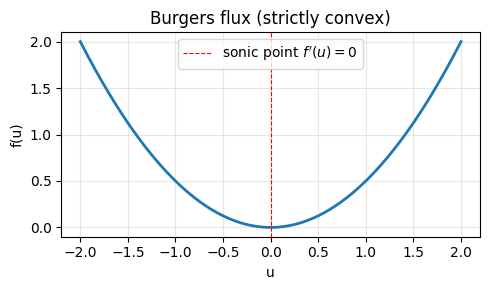

In [2]:
us = torch.linspace(-2.0, 2.0, 201, dtype=torch.float64)
fs = burgers_flux(us)

plt.figure(figsize=(5, 3))
plt.plot(us.numpy(), fs.numpy(), lw=2)
plt.axvline(0.0, color='r', linestyle='--', lw=0.8, label='sonic point $f\'(u)=0$')
plt.xlabel('u'); plt.ylabel('f(u)')
plt.title('Burgers flux (strictly convex)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 2. Pure shock: $u_L=1,\;u_R=-1$

Rankine–Hugoniot shock speed is $(u_L + u_R)/2 = 0$. The shock should remain at $x = x_{\rm split}$ for all time, since $u_L > u_R$ and both fluxes equal $1/2$.

valid: True


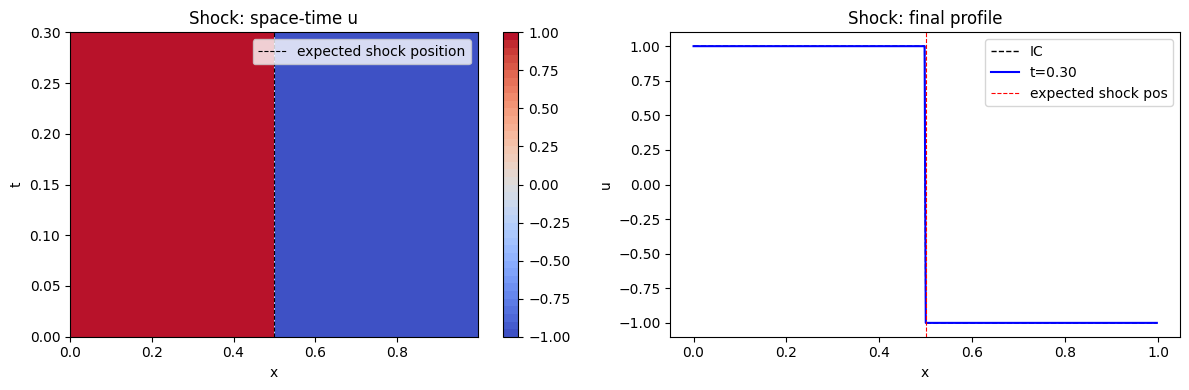

In [3]:
x_split = 0.5
u0 = riemann(x, u_left=1.0, u_right=-1.0, x_split=x_split)
sol = generate_one(u0, dx=DX, dt=DT, nt=NT, flux_type='godunov', reconstruction='constant')
print('valid:', sol['valid'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
c = axes[0].contourf(sol['x'].numpy(), sol['t'].numpy(), sol['u'].numpy(), levels=40, cmap='coolwarm')
fig.colorbar(c, ax=axes[0]); axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].axvline(x_split, color='k', lw=0.8, linestyle='--', label='expected shock position')
axes[0].set_title('Shock: space-time u')
axes[0].legend()

axes[1].plot(sol['x'].numpy(), sol['u'][0].numpy(), 'k--', lw=1, label='IC')
axes[1].plot(sol['x'].numpy(), sol['u'][-1].numpy(), 'b-', lw=1.5, label=f't={sol["t"][-1]:.2f}')
axes[1].axvline(x_split, color='r', lw=0.8, linestyle='--', label='expected shock pos')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u'); axes[1].legend()
axes[1].set_title('Shock: final profile')
fig.tight_layout(); plt.show()

## 3. Pure rarefaction: $u_L=-1,\;u_R=1$ (transonic)

Analytical solution is a centred rarefaction fan $u = (x - x_{\rm split})/t$ inside $[-t, t]$ and the left/right states outside. The entropy fix in the Godunov flux is essential here — without it, a stationary expansion shock would remain at $x_{\rm split}$.

valid: True


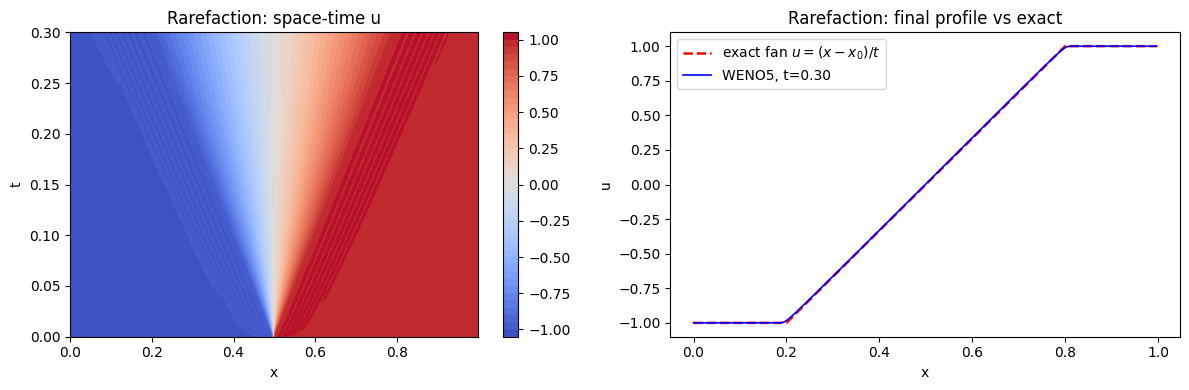

In [4]:
u0 = riemann(x, u_left=-1.0, u_right=1.0, x_split=x_split)
sol = generate_one(u0, dx=DX, dt=DT, nt=NT, flux_type='godunov', reconstruction='weno5')
print('valid:', sol['valid'])

t_final = float(sol['t'][-1])
exact_fan = ((sol['x'] - x_split) / t_final).clamp(-1.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
c = axes[0].contourf(sol['x'].numpy(), sol['t'].numpy(), sol['u'].numpy(), levels=40, cmap='coolwarm')
fig.colorbar(c, ax=axes[0]); axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].set_title('Rarefaction: space-time u')

axes[1].plot(sol['x'].numpy(), exact_fan.numpy(), 'r--', lw=1.8, label='exact fan $u=(x-x_0)/t$')
axes[1].plot(sol['x'].numpy(), sol['u'][-1].numpy(), 'b-', lw=1.2, label=f'WENO5, t={t_final:.2f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u'); axes[1].legend()
axes[1].set_title('Rarefaction: final profile vs exact')
fig.tight_layout(); plt.show()

## 4. Transonic entropy-fix sanity

Mixed-sign Riemann problem $u_L=-0.5,\;u_R=1.0$: the sonic point $u=0$ lies strictly inside $[u_L, u_R]$, so the entropy-admissible solution is a centered rarefaction fan through zero. The Godunov flux in this notebook includes the entropy fix (`f=0` when $u_L<0<u_R$) so the numerical solution should match the exact fan.

valid: True


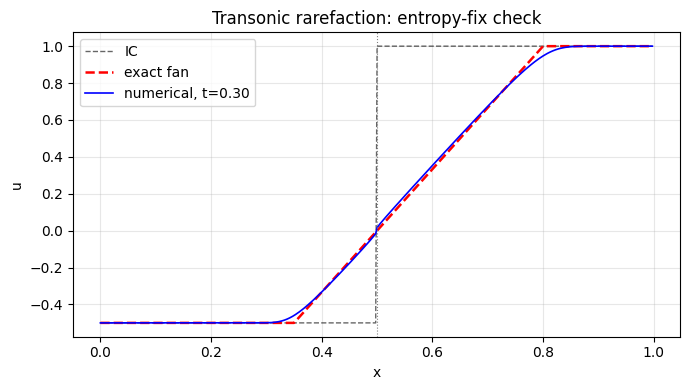

u at sonic point x=0.5: 1.6282e-02  (expect ~ 0)


In [5]:
u0 = riemann(x, u_left=-0.5, u_right=1.0, x_split=x_split)
sol = generate_one(u0, dx=DX, dt=DT, nt=NT, flux_type='godunov', reconstruction='constant')
print('valid:', sol['valid'])

t_final = float(sol['t'][-1])
exact_fan = ((sol['x'] - x_split) / t_final).clamp(-0.5, 1.0)

plt.figure(figsize=(7, 4))
plt.plot(sol['x'].numpy(), sol['u'][0].numpy(), 'k--', lw=1, alpha=0.6, label='IC')
plt.plot(sol['x'].numpy(), exact_fan.numpy(), 'r--', lw=1.8, label='exact fan')
plt.plot(sol['x'].numpy(), sol['u'][-1].numpy(), 'b-', lw=1.2, label=f'numerical, t={t_final:.2f}')
plt.axvline(x_split, color='grey', lw=0.8, linestyle=':')
plt.xlabel('x'); plt.ylabel('u'); plt.legend()
plt.title('Transonic rarefaction: entropy-fix check')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

idx_split = int(x_split / DX)
print(f'u at sonic point x={x_split}: {sol["u"][-1, idx_split].item():.4e}  (expect ~ 0)')

## 5. Piecewise IC: constant vs WENO5

Compare first-order Godunov against WENO-5 on a 5-piece random IC: WENO-5 should resolve rarefactions more sharply while still capturing shocks without oscillations.

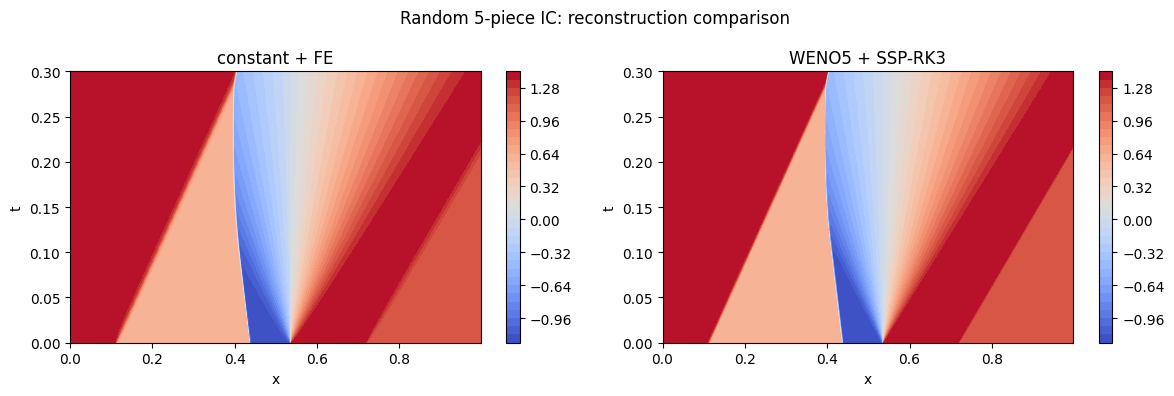

In [6]:
rng = torch.Generator(); rng.manual_seed(0)
from numerical_solvers.src.burgers.initial_conditions import random_piecewise

u0, _ = random_piecewise(x, k=5, rng=rng, u_range=(-1.5, 1.5))

sol_c = generate_one(u0, dx=DX, dt=DT, nt=NT, flux_type='godunov', reconstruction='constant')
sol_w = generate_one(u0, dx=DX, dt=DT, nt=NT, flux_type='godunov', reconstruction='weno5')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sol, title in zip(axes, [sol_c, sol_w], ['constant + FE', 'WENO5 + SSP-RK3']):
    c = ax.contourf(sol['x'].numpy(), sol['t'].numpy(), sol['u'].numpy(), levels=40, cmap='coolwarm')
    fig.colorbar(c, ax=ax); ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title(title)
fig.suptitle('Random 5-piece IC: reconstruction comparison')
fig.tight_layout(); plt.show()

## 6. `generate_n`: small batch of random samples

u shape: torch.Size([6, 601, 400])
ic_xs shape: (6, 4) ic_u_ks shape: (6, 3)


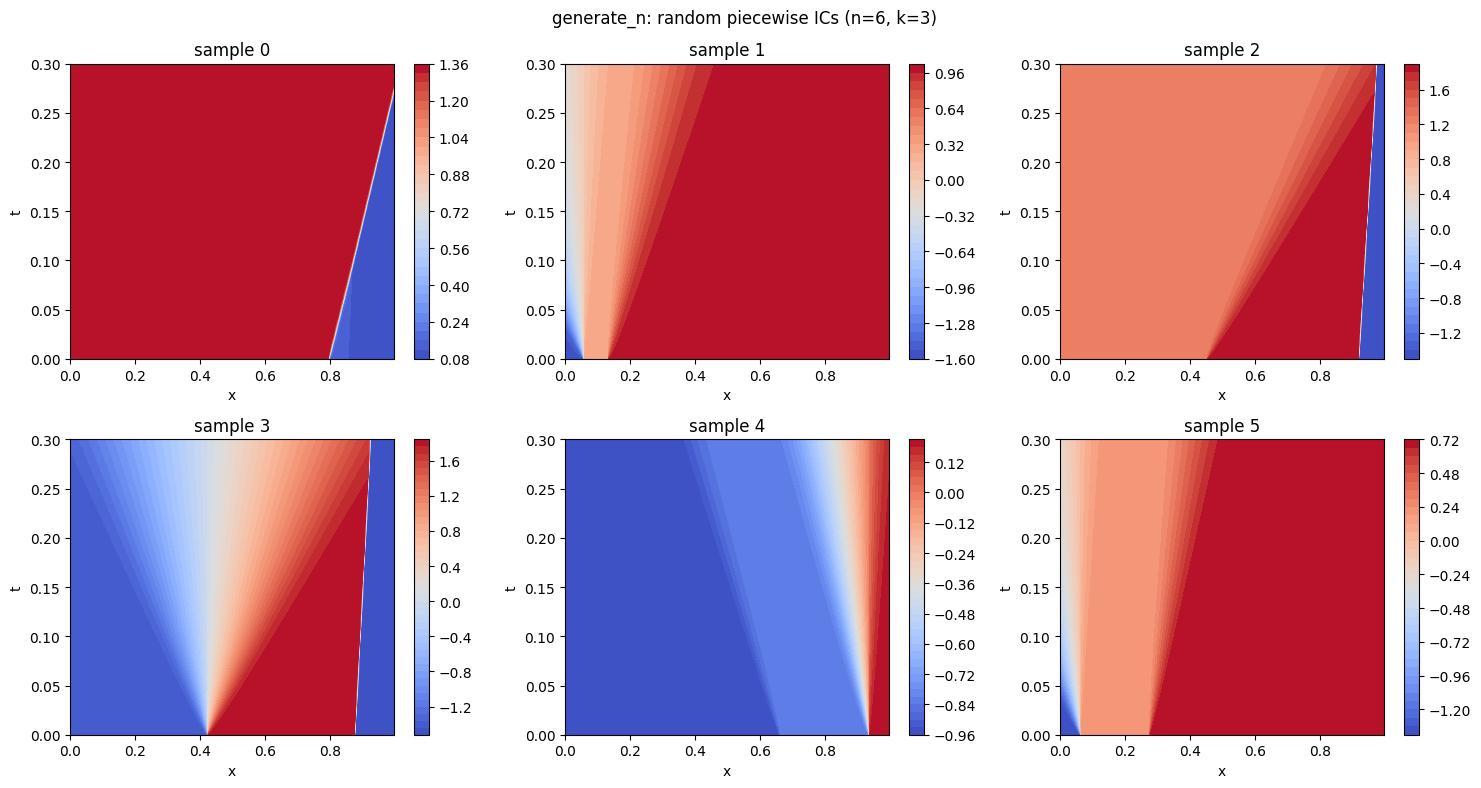

In [7]:
batch = generate_n(n=6, k=3, nx=NX, dx=DX, dt=DT, nt=NT, seed=42, reconstruction='constant', show_progress=False)
print('u shape:', batch['u'].shape)
print('ic_xs shape:', batch['ic_xs'].shape, 'ic_u_ks shape:', batch['ic_u_ks'].shape)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    c = ax.contourf(batch['x'].numpy(), batch['t'].numpy(), batch['u'][i].numpy(), levels=40, cmap='coolwarm')
    fig.colorbar(c, ax=ax); ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title(f'sample {i}')
fig.suptitle('generate_n: random piecewise ICs (n=6, k=3)')
fig.tight_layout(); plt.show()